# Pragmatic Model Evaluation 

## Feature Selection and Engineering

### Motivation

In certain contexts, it is very important to select and/or engineer useful features to feed into your ML models.

If you feed your Machine Learning methods poor features from your dataset, you can expect to get poor models out.
(The cliché is "Garbage in, Garbage out").

So, we need to identify or even create independent variables that can inform us about the dependent variable. The set of inputs *X* should predict the target variable *y*. Things that do not relate to  *y* should not be included, like noise or constants.

The process of identifying which of our features we should use as input to our model is known as *feature selection*. 

Some datasets can have thousands, millions, or even billions of features (for example, when working with genome data). Even with smaller datasets, some ML algorithms perform poorly when correlated or noisy variables are included (e.g. linear regression), and can greatly benefit from from feature selection. More generally, models made with all available features may be over-complicated, lack generalisation and can be hard to interpret. ML models should be parsimonious, simple as possible, with low error. Otherwise, models get mis-interpreted, take too long to run, or fit the noise (over-fit)!

The process of creating new features from the data is known as *feature engineering*. This can include:
+ multiplying columns together in tabular data
+ highlighting edges or regions of images 
+ PCA: rotating the axes you are using to more sensible ones and selecting information-rich features
+ transforming variables by applying arbitrary functions to them
+ making sure all required variables are available, not just using those readily available.

Feature engineering contributes to explainability, speeds-up training, and decreases over-fitting.

In fact, feature selection and engineering are often applied iteratively: 
Get features --> make ML model --> model optimization --> improve features --> make new model --> improve features...

In [5]:
# Load relevant libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Getting to know this dataset

## Dataset: Boston Housing Data

**Dependent Variable**: 

MEDV: Median value of owner-occupied homes in 1000's of dollars

**Explanatory Variables**

CRIM: per capita crime rate by town

ZN: proportion of residential land zoned for lots over 25,000 sq.ft.

INDUS: proportion of non-retail business acres per town

CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)

NOX: nitric oxides concentration (parts per 10 million)

RM: average number of rooms per dwelling

AGE: proportion of owner-occupied units built prior to 1940

DIS: weighted distances to five Boston employment centres

RAD: index of accessibility to radial highways

TAX: full-value property-tax rate per 10,000 dollars

PTRATIO: pupil-teacher ratio by town

B: 1000(Bk - 0.63)^2 where Bk is the proportion of black residents by town

LSTAT: lower status of the population 

In [6]:
df = pd.read_csv("../data/boston_housing.csv")

df.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


## Evaluating correlation between variables

**Q1**. Use pairplot function of `seaborn` to get a matrix of correlation plots between the variables.

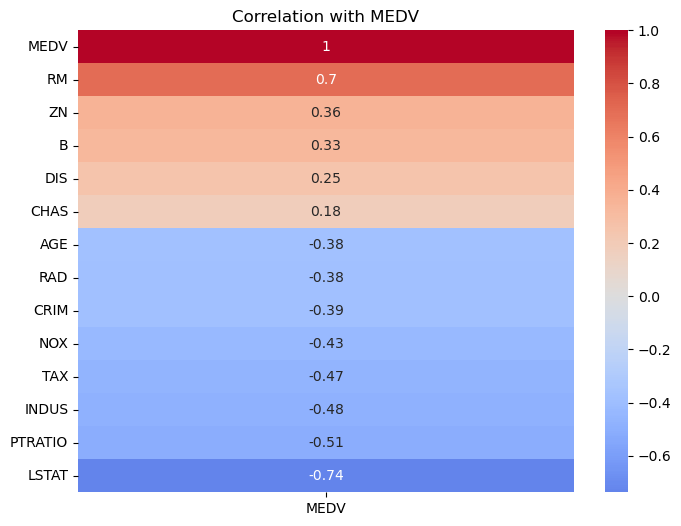

In [7]:
# Your code here...
# sns.pairplot(df)
# plt.show()

# Heatmap showing correlations with MEDV
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr()[['MEDV']].sort_values(by='MEDV', ascending=False), 
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlation with MEDV')
plt.show()

**Q2**. Calculate the correlation coefficient for variable AGE and the target, MEDV.

In [8]:
from scipy.stats import pearsonr

# Your code here...
corr, p_value = pearsonr(df['AGE'], df['MEDV'])
print(f"Correlation coefficient between AGE and MEDV: {corr:.4f}")
print(f"P-value: {p_value:.4e}")

Correlation coefficient between AGE and MEDV: -0.3770
P-value: 1.5700e-18


**Q3**. Calculate the correlation coefficient for variable RM and the target, MEDV.

In [9]:
# Your code here...
corr, p_value = pearsonr(df['RM'], df['MEDV'])
print(f"Correlation coefficient between RM and MEDV: {corr:.4f}")
print(f"P-value: {p_value:.4e}")


Correlation coefficient between RM and MEDV: 0.6954
P-value: 2.4872e-74


**Q4**.  Identify the best features using the Kendall Tau correlation coefficient. 

Hint: you can use corr function, where the method can be specified as 'kendall'

In [10]:
# Your code here...
# Calculate Kendall Tau correlation coefficients with MEDV
kendall_corr = df.corr(method='kendall')['MEDV'].sort_values(ascending=False)
print("Kendall Tau correlation coefficients with MEDV:\n")
print(kendall_corr)

Kendall Tau correlation coefficients with MEDV:

MEDV       1.000000
RM         0.482829
ZN         0.339989
DIS        0.313115
B          0.126955
CHAS       0.115202
RAD       -0.248115
AGE       -0.387758
NOX       -0.394995
PTRATIO   -0.398789
CRIM      -0.403964
TAX       -0.414650
INDUS     -0.418430
LSTAT     -0.668656
Name: MEDV, dtype: float64


## Removing variables with low information content

ML models should be made without using all available variables, hence we should remove some.

A) A simple way to do this is to remove those that are not correlated with the target variable (E.g. MEDV as in the above example).

B) Another way is to remove variables that correlate strongly with each other (remove all but one).


PCA is a robust method for removing dimensions (features) that have linear correlations with each other.

**Q4**. Remove the variables that have a low correlation with MEDV. Remove any variable that has correlation less than 0.03, with the target variable.

For this, write a function name `keep_predictors` and take 3 args: `df`, `targ` - the target variable - and `cor_thresh` - the correlation threshold.

_Hints: Import `deepcopy` from `copy` (that does not change the original data frame) and please remember to use `abs()` values._

In [11]:
# Your code here...
from copy import deepcopy

def keep_predictors(df, targ, cor_thresh):
    df_copy = deepcopy(df)
    cor_matrix = df_copy.corr()
    
    # Get features with absolute correlation > threshold with target
    relevant_features = cor_matrix.index[abs(cor_matrix[targ.name]) > cor_thresh]
    
    return df_copy[relevant_features]

In [12]:
targ = df["MEDV"]
df_redu = keep_predictors(df,targ,0.03)
df_redu.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


**Q5**. Remove one of a pair of the remaining variables that have high correlations with each other.

For this purpose, write a function name `remove_correlated` that takes 2 args: `df` and `cor_thresh1` - the correlation threshold.


In [25]:
# Your code here...
def remove_correlated(df, cor_thresh1, target_col=None):
    """
    Remove highly correlated features from a DataFrame to avoid multicollinearity.
    
    When two features are highly correlated (above the threshold), this function intelligently
    keeps the one with STRONGER correlation to the target variable (if target is specified).
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe with features
    cor_thresh1 : float
        Correlation threshold (e.g., 0.8). Pairs of features with correlation above this are candidates for removal.
    target_col : str, optional
        Name of target column. If provided, keeps the feature with higher target correlation.
        If None and 'MEDV' exists in df, uses 'MEDV' as target.
    
    Returns:
    --------
    DataFrame with highly correlated features removed
    """
    df_copy = deepcopy(df)
    
    # Calculate absolute correlation matrix
    cor_matrix = df_copy.corr().abs()
    
    # Determine target column for smart dropping
    if target_col is None and 'MEDV' in df_copy.columns:
        target_col = 'MEDV'
    
    # Get upper triangle of correlation matrix (avoids checking same pair twice)
    # k=1 means diagonal is excluded (a variable always correlates perfectly with itself)
    upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))
    
    to_drop = set()
    
    # Smart dropping: keep variable with higher target correlation
    if target_col and target_col in df_copy.columns:
        target_corr = cor_matrix[target_col]
        
        for col in upper_tri.columns:
            if col not in to_drop and col != target_col:
                for row in upper_tri.index:
                    if row != target_col and row not in to_drop:
                        if upper_tri.loc[row, col] > cor_thresh1:
                            # Drop the one with LOWER correlation to target
                            if target_corr[row] < target_corr[col]:
                                to_drop.add(row)
                                print(f"Dropping {row} (corr with target: {target_corr[row]:.3f}) over {col} (corr with target: {target_corr[col]:.3f})")
                            else:
                                to_drop.add(col)
                                print(f"Dropping {col} (corr with target: {target_corr[col]:.3f}) over {row} (corr with target: {target_corr[row]:.3f})")
                            break  # Move to next column once we've handled this pair
    else:
        # Fallback: simple dropping based on column order
        to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > cor_thresh1)]
    
    return df_copy.drop(columns=list(to_drop))

You may test the function, `remove_correlated` with the following code:

In [26]:
cor_thresh1 = 0.8
boston_minimal = remove_correlated(df, cor_thresh1)
boston_minimal.head(14)

Dropping RAD (corr with target: 0.382) over TAX (corr with target: 0.469)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,311,15.2,386.71,17.10,18.9


# Principle Component Analysis (PCA)

## PCA and z-score normalisation.

PCA looks for the most variance, so can be biased based on size of values (larger values can easily have more variance). Hence data need to be mormalised before applying PCA on it. 

**Q6**. Drop the target variable, "MEDV" from the original dataset, and call it `boston_x`.

In [16]:
# Your code here...
boston_x = df.drop('MEDV', axis=1)
boston_x.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


**Q7**. Use `StandardScaler` from `sklearn.preprocessing`, to transform the input data to z-score values.

In [ ]:
# Your code here...
"""
StandardScaler transforms features to have:
- Mean = 0 (centered)
- Standard deviation = 1 (normalized)

This is called z-score normalization: z = (x - μ) / σ

Why is this important for PCA?
- PCA is sensitive to the scale of features
- Features with larger values/variance dominate the principal components
- Scaling ensures all features contribute equally based on their variance structure, not their units
"""

from sklearn.preprocessing import StandardScaler

# Create scaler instance
scaler = StandardScaler()

# Fit to data (calculate mean & std) and transform (apply z-score formula)
boston_x_scaled = scaler.fit_transform(boston_x)

print(f"Original data shape: {boston_x.shape}")
print(f"Scaled data shape: {boston_x_scaled.shape}")
print(f"\nFirst few values of scaled data:\n{boston_x_scaled[:5]}")

Original data shape: (506, 13)
Scaled data shape: (506, 13)

First few values of scaled data:
[[-0.41978194  0.28482986 -1.2879095  -0.27259857 -0.14421743  0.41367189
  -0.12001342  0.1402136  -0.98284286 -0.66660821 -1.45900038  0.44105193
  -1.0755623 ]
 [-0.41733926 -0.48772236 -0.59338101 -0.27259857 -0.74026221  0.19427445
   0.36716642  0.55715988 -0.8678825  -0.98732948 -0.30309415  0.44105193
  -0.49243937]
 [-0.41734159 -0.48772236 -0.59338101 -0.27259857 -0.74026221  1.28271368
  -0.26581176  0.55715988 -0.8678825  -0.98732948 -0.30309415  0.39642699
  -1.2087274 ]
 [-0.41675042 -0.48772236 -1.30687771 -0.27259857 -0.83528384  1.01630251
  -0.80988851  1.07773662 -0.75292215 -1.10611514  0.1130321   0.41616284
  -1.36151682]
 [-0.41248185 -0.48772236 -1.30687771 -0.27259857 -0.83528384  1.22857665
  -0.51117971  1.07773662 -0.75292215 -1.10611514  0.1130321   0.44105193
  -1.02650148]]


**Q8**. Now, use Principal Component Analysis (PCA) to reduce the dimensionality of this dataset to 5 Principal Components (PCs).

PCA operation can be imported from the decomposition package of the sklearn.

Save outputs of your PCA to the variable `pca`.

In [18]:
# Your code here...
from sklearn.decomposition import PCA
# Create PCA instance to reduce to 5 components
pca = PCA(n_components=5)

**Q9**. Get the explained variance ratios of these first few PCs.

Hint: use the attribute called explained_variance_ratio_ 

Print their sum below too.

In [19]:
# Your code here...
# Fit PCA to the scaled data and transform it
boston_pca = pca.fit_transform(boston_x_scaled)

# Get explained variance ratios for each component
variance_ratios = pca.explained_variance_ratio_

print("Explained variance ratio for each principal component:")
for i, ratio in enumerate(variance_ratios, 1):
    print(f"PC{i}: {ratio:.4f} ({ratio*100:.2f}%)")

print(f"\nTotal variance explained by {pca.n_components_} components: {variance_ratios.sum():.4f} ({variance_ratios.sum()*100:.2f}%)")

Explained variance ratio for each principal component:
PC1: 0.4713 (47.13%)
PC2: 0.1103 (11.03%)
PC3: 0.0956 (9.56%)
PC4: 0.0660 (6.60%)
PC5: 0.0642 (6.42%)

Total variance explained by 5 components: 0.8073 (80.73%)


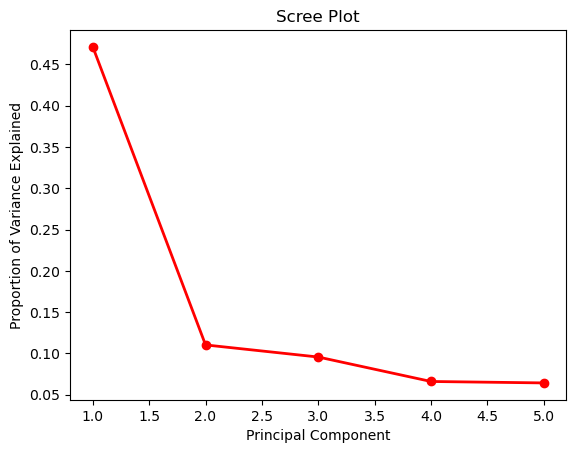

In [20]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'ro-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.show()

So the PCs selected don't explain all the variance, but should explain most of it.

The Pareto Principle says that people can get most of the work done by focusing on a small percentage of the work.

This is also called the 80-20 Rule: For example: you can get 80% of success by focusing on only 20% of the tasks.

OR an even better possibility, 90% of success by focusing on only 15% of the tasks. 

**Bonus**

If you would like to know what went into making the PC, the following exercise will focus on that. 

What factors have the most variance in this dataset?
(Could be related to predicting MEDV, the median values of houses.)

Giving you the answer here, see seralouk's answer:

https://stackoverflow.com/questions/22984335/recovering-features-names-of-explained-variance-ratio-in-pca-with-sklearn

**Q10 bonus**. Extract the features present from the PCs.

_Hint: `pca.components_`_ may be helpful

In [28]:
# Your code here...
model = PCA(n_components=5).fit(boston_x_scaled)
X_pc = model.transform(boston_x_scaled)
initial_feature_names=df.columns
# number of components
n_pcs= model.components_.shape[0]

# get the index of the most important feature on EACH component i.e. largest absolute value
# using LIST COMPREHENSION HERE
most_important = [np.abs(model.components_[i]).argmax() for i in range(n_pcs)]


# get the names
most_important_names = [initial_feature_names[most_important[i]] for i in range(n_pcs)]

# using LIST COMPREHENSION HERE AGAIN
dic = {'PC{}'.format(i+1): most_important_names[i] for i in range(n_pcs)}

# build the dataframe
feature_df = pd.DataFrame(sorted(dic.items()))
print(feature_df)

     0        1
0  PC1    INDUS
1  PC2     CHAS
2  PC3       RM
3  PC4     CHAS
4  PC5  PTRATIO


Some of these features might be important in more than 1 principle component.

Remember that having these un-rotated variables is not the point of PCA, the point is to rotate the data to a more variance-centric view, and to remove what is not needed by selecting only a few number of variables of all the available variables.

## Mutual Information (MI)

PCA is a brilliant way to remove correlated variables but it only notices linear relationships between variables.

Mutual Information (MI) on the other hand finds **all** relationships.

Mutual information is a method of finding relationships between variables. 

MI measures how much certainty can be gained about Variable 2 by knowing Variable 1.

The amount of 'uncertainty' is measured by entropy. 
Entropy is a fundamental measure used in Information Theory, which is the average  amount of information or certainty in a variable's possible outcomes. 

Entropy is the expected value of the information content. Shannon Information or the "level of surprise" of a variable, signifies how surprising a variable or message is on average.

Information content has units of bits or *shannons*. If an event is unlikely, then it is more surprising and informative when it does happen. So, the value of information content decreases as the probability of its occurrence increases.

Information, $I$, is defined as 
$I(E)=-log_2(P(E))$ 
where $E$ is an event, $P(E)$ is the probability of Event happening, and $log_2$ is logarithm base 2.
https://en.wikipedia.org/wiki/Entropy_(information_theory)

Value for MI can be in the range of zero to infinity.
$$I(X;Y) = D_{KL}(P_{X,Y}|| P_X x P_Y)$$

Where $D_{KL}$ is the Kullback-Liebler divergence, $P_{X,Y}$ is the joint distributions and $P_X$ and $P_Y$ are the marginal distributions.

A marginal distribution https://en.wikipedia.org/wiki/Marginal_distribution

**Q11**. 
Calculate the mutual information score between variables df["RM"] and df["CRIM"].

_Hint: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mutual_info_score.html_

In [29]:
# Your code here...
# Mutual Information score
from sklearn.metrics import mutual_info_score
mutual_info_score(df["RM"], df["CRIM"])

c:\Users\ssmith1\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and continuous values for target
  warnings.warn(msg, UserWarning)


np.float64(6.050469990923788)

**Q12**. Get the mutual information scores for all variables in `df` vs the target, "MEDV" and print them out. 

Hint: for this, you may use the mutual_info_regression function

In [30]:
# Your code here...
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y):
    ""
    mi_scores = mutual_info_regression(X, y)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

# df.iloc[:, :-1] means to remove final column
mi_scores = make_mi_scores(df.iloc[:, :-1], df["MEDV"])
mi_scores[:3]  # show top 3 features with their MI scores

LSTAT    0.669767
RM       0.529115
INDUS    0.469456
Name: MI Scores, dtype: float64

Interpretation: 
LSTAT has the most mutual information with MEDV, the target. 

Credit: Kaggle Mutual Information

## Additional Material: Genetic Algorithms: evolving features

Genetic Algorithms can also be an effective and cool tool to select features.

You may find out more about them here: https://pypi.org/project/sklearn-genetic/#description

### Extra tool you could read about if you like:
A tool you can use for generating new features from original ones:

[tsfresh](https://tsfresh.readthedocs.io/en/latest/text/quick_start.html)

# Conclusions

During the lesson, we have seen some examples of feature selection before the ML models are trained.

Instead, feature engineering should be an iterative process.

So, the features are improved after the ML model is trained, then do a new ML model. Iterate!

Also, don't forget to tune hyperparameters of the ML model.

In this practical we have seen how feature selection can be done in 3 different ways:

+ Mutual Information
+ Conditional entropy
+ Information gain
